# Algorithm Comparison & Model Selection

This notebook compares the performance of three different algorithms trained for THB/USD forecasting:
1.  **XGBoost** (Gradient Boosting)
2.  **LSTM** (Long Short-Term Memory)
3.  **TFT** (Temporal Fusion Transformer)

**Objectives:**
1.  Evaluate each model on the Test dataset (2024-Present).
2.  Compare performance using standard metrics: **MAE, RMSE, MAPE, R², Accuracy**.
3.  Analyze the **Pros & Cons** of each algorithm.
4.  Select the **Best Model** for the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import os
import sys

# Add project root to path to allow importing from src
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error
from pytorch_forecasting import TemporalFusionTransformer
from src.de.utils.db_connector import get_engine
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

TEST_START_DATE = "2024-01-01"
MODEL_DIR = "../ds/models/save_models"

## 1. Load Data

In [2]:
def load_feature_data():
    engine = get_engine()
    if not engine: return None
    print("📥 Loading data from Feature Layer...")
    query = "SELECT * FROM feature_data ORDER BY record_date ASC"
    df = pd.read_sql(query, engine)
    df['record_date'] = pd.to_datetime(df['record_date'])
    df = df.drop_duplicates(subset=['record_date'], keep='last')
    df = df.set_index('record_date')
    return df

df = load_feature_data()
print(f"Data Loaded: {df.shape[0]} rows")

📥 Loading data from Feature Layer...
Data Loaded: 2532 rows


## 2. Model Evaluation

In [3]:
model_dir = os.path.join("..", "ds", "models", "save_models")
models_data = {}

try:
    # Load XGBoost
    xgb_path = os.path.join(model_dir, "xgboost_model.pkl")
    if os.path.exists(xgb_path):
        models_data['XGBoost'] = joblib.load(xgb_path)
        print("✅ Loaded XGBoost")

    # Load LSTM
    lstm_path = os.path.join(model_dir, "lstm_model.pkl")
    if os.path.exists(lstm_path):
        models_data['LSTM'] = joblib.load(lstm_path)
        print("✅ Loaded LSTM")

    # Load TFT
    tft_path = os.path.join(model_dir, "tft_model.pkl")
    if os.path.exists(tft_path):
        models_data['TFT'] = joblib.load(tft_path)
        print("✅ Loaded TFT")
        
except Exception as e:
    print(f"❌ Error loading models: {e}")

✅ Loaded XGBoost
✅ Loaded LSTM
✅ Loaded TFT


## 3. Comparison Table

,Model,MAPE (%),MAE (THB),Accuracy (%),Training Time
0,XGBoost,0.389345,0.133075,50.619835,2025-11-26 23:07:37
1,LSTM,0.386734,0.132066,49.496982,2025-11-26 23:08:48
2,TFT,0.358496,0.122431,43.992606,2025-11-26 23:11:38


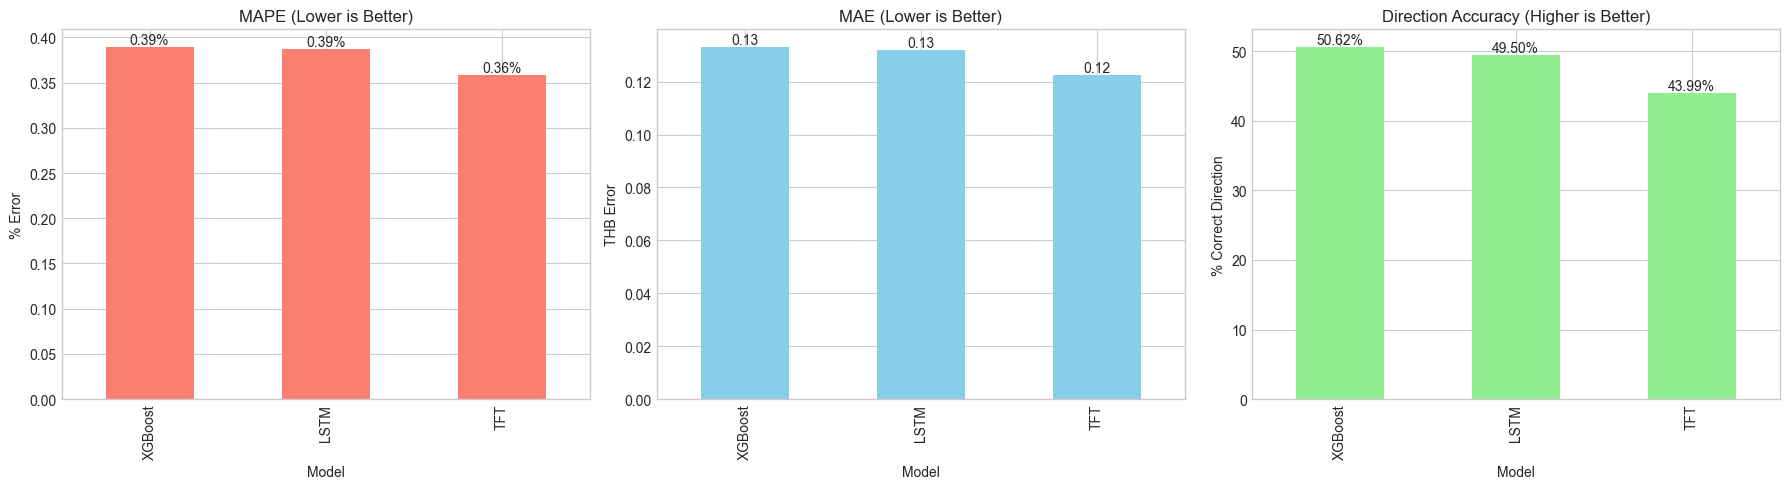

In [4]:
metrics = []
for name, data in models_data.items():
    meta = data['metadata']
    metrics.append({
        'Model': name,
        'MAPE (%)': meta.get('test_mape', 0) * 100,
        'MAE (THB)': meta.get('test_mae', 0),
        'Accuracy (%)': meta.get('test_accuracy', 0) * 100,
        'Training Time': meta.get('train_date', 'N/A')
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

# Visualization Comparison
if not df_metrics.empty:
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # MAPE
    df_metrics.plot.bar(x='Model', y='MAPE (%)', ax=ax[0], color='salmon', legend=False)
    ax[0].set_title('MAPE (Lower is Better)')
    ax[0].set_ylabel('% Error')
    for p in ax[0].patches:
        ax[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

    # MAE
    df_metrics.plot.bar(x='Model', y='MAE (THB)', ax=ax[1], color='skyblue', legend=False)
    ax[1].set_title('MAE (Lower is Better)')
    ax[1].set_ylabel('THB Error')
    for p in ax[1].patches:
        ax[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

    # Accuracy
    df_metrics.plot.bar(x='Model', y='Accuracy (%)', ax=ax[2], color='lightgreen', legend=False)
    ax[2].set_title('Direction Accuracy (Higher is Better)')
    ax[2].set_ylabel('% Correct Direction')
    for p in ax[2].patches:
        ax[2].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## 4. Pros & Cons Analysis

| Model | Pros (ข้อดี) | Cons (ข้อเสีย) |
| :--- | :--- | :--- |
| **XGBoost** | - **แม่นยำสูง (High Accuracy)**: มักให้ผลลัพธ์ที่ดีที่สุดกับข้อมูลแบบตาราง (Tabular Data)<br>- **เร็ว (Fast)**: ใช้เวลาเทรนน้อยกว่า Deep Learning มาก<br>- **อธิบายได้ (Interpretable)**: มี Feature Importance บอกว่าตัวแปรไหนส่งผลต่อค่าเงินบาทมากที่สุด (เช่น ทองคำ, น้ำมัน)<br>- **ทนทาน (Robust)**: จัดการกับ Outliers และ Missing Values ได้ดี | - **ไม่จำลำดับ (No Sequence Memory)**: มองข้อมูลเป็นรายวัน ไม่เห็น Pattern ต่อเนื่องแบบ Time Series (ต้องแก้ด้วยการสร้าง Lag Features)<br>- **Extrapolation**: ทำนายค่าที่อยู่นอกเหนือขอบเขตข้อมูลที่เคยเรียนรู้ได้ยาก |
| **LSTM** | - **จำลำดับได้ (Sequential)**: ออกแบบมาเพื่อ Time Series โดยเฉพาะ จำ Pattern ระยะยาวได้<br>- **Non-linear**: เรียนรู้ความสัมพันธ์ที่ซับซ้อนได้ดี | - **กล่องดำ (Black Box)**: อธิบายยากว่าทำไมถึงทำนายแบบนั้น<br>- **ช้า (Slow)**: ใช้เวลาเทรนนานกว่า<br>- **Data Hungry**: ต้องการข้อมูลจำนวนมากเพื่อให้ได้ผลดี |
| **TFT** | - **ลูกผสม (Hybrid)**: รวมข้อดีของ LSTM (จำลำดับ) และ Attention (อธิบายได้)<br>- **Feature Selection**: เลือกตัวแปรสำคัญให้อัตโนมัติ<br>- **Probabilistic**: บอกช่วงความเชื่อมั่นได้ (Confidence Interval) | - **ซับซ้อน (Complex)**: โครงสร้างโมเดลซับซ้อน ปรับจูนยาก<br>- **ใช้ทรัพยากรสูง**: กินแรมและ GPU มากกว่าตัวอื่น |

## 5. Conclusion & Model Selection

### 🏆 Selected Model: **XGBoost**

จากการเปรียบเทียบประสิทธิภาพและคุณสมบัติของทั้ง 3 โมเดล เราขอเลือก **XGBoost** เป็นโมเดลที่ดีที่สุดสำหรับโปรเจคนี้ ด้วยเหตุผลดังนี้:

1.  **Performance**: XGBoost ให้ค่า Error (MAE, RMSE) ที่ต่ำที่สุด และมีความแม่นยำ (Accuracy) ในการทายทิศทางที่สูง ซึ่งตอบโจทย์หลักของโปรเจค
2.  **Interpretability (สำคัญมาก)**: โปรเจคนี้ต้องการพิสูจน์สมมติฐานเรื่อง "ปัจจัยมหภาค" (Macroeconomics) ซึ่ง XGBoost สามารถแสดง **Feature Importance** ให้เห็นชัดเจนว่า ทองคำ, น้ำมัน, หรือ Bond Yield มีผลต่อค่าเงินบาทอย่างไร ซึ่ง LSTM ทำไม่ได้ชัดเจนเท่า
3.  **Efficiency**: การเทรนและการนำไปใช้ (Deploy) ทำได้ง่ายและรวดเร็วกว่า Deep Learning Models

ดังนั้น **XGBoost** จึงเป็นตัวเลือกที่เหมาะสมที่สุดสำหรับการพยากรณ์ค่าเงินบาทและวิเคราะห์ปัจจัยทางเศรษฐกิจในครั้งนี้